In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random as rand
import scipy
from scipy.optimize import fsolve
import os
from tqdm import tqdm
import sys
from class_comparts import *
from colorsarr import colorsarr
colarr = colorsarr()
carr = colarr.carr
cd = os.getcwd()

/tmp/ipykernel_7593/3106477973.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0., 0.2, 0.4, 0.6, 0.8, 1.], fontsize=15)
/tmp/ipykernel_7593/3106477973.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([0., 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 4.], fontsize=15)
/tmp/ipykernel_7593/3106477973.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0., 0.2, 0.4, 0.6, 0.8, 1.], fontsize=15)
/tmp/ipykernel_7593/3106477973.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([0., 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 4.], fontsize=15)


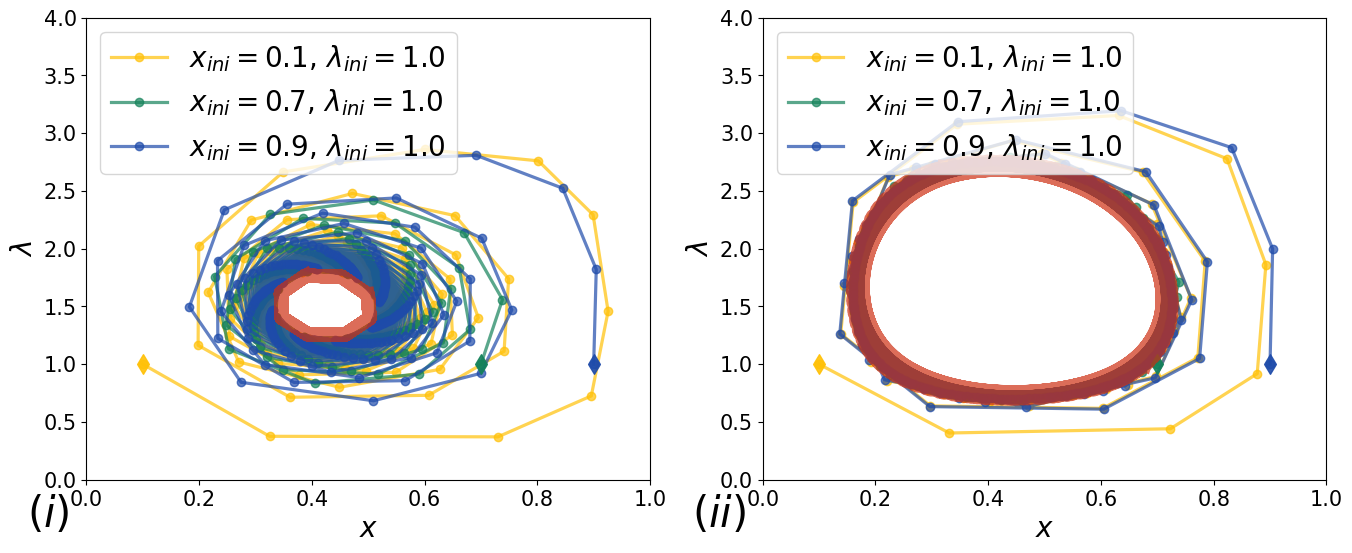

In [2]:
# 2 species with class #

repet = int(3E2)
cells = 5.E4
r=1

alpha = np.array([[5.E-1,0.],[0.,2.E0]])
gamma = np.array([[7.E0,0.],[0.,2.E1]])
mu = np.array([0.,0.])
nu = np.array([0.,0.])



Klist, d = [29, 32], 10
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

for j, ax in enumerate([ax1, ax2]):
    K = Klist[j]
    T=1.E0*K/(alpha[0][0]*(K+1))
    x00, x01, x02, lam0, = 0.1, 0.7, 0.9, 1.

    xlist0, xlist1, xlist2, lamlist0, lamlist1, lamlist2 = [x00], [x01], [x02], [lam0], [lam0], [lam0]

    compart_dyn_theo_deter = theory_compart(T, K, d, x00, 0., 1-x00, 1., repet, alpha, gamma, mu, nu, ratiolen = r)
    hist_evol_theo, hist_evol_theo_numb, lamlist0 = compart_dyn_theo_deter.evol(lambdaarr=True)
    hist_evol_theo = np.array(hist_evol_theo)
    xlist0 = hist_evol_theo[:-1,0,0] + hist_evol_theo[:-1,0,1]

    compart_dyn_theo_deter = theory_compart(T, K, d, x01, 0., 1-x01, 1., repet, alpha, gamma, mu, nu, ratiolen = r)
    hist_evol_theo, hist_evol_theo_numb, lamlist1 = compart_dyn_theo_deter.evol(lambdaarr=True)
    hist_evol_theo = np.array(hist_evol_theo)
    xlist1 = hist_evol_theo[:-1,0,0] + hist_evol_theo[:-1,0,1]

    compart_dyn_theo_deter = theory_compart(T, K, d, x02, 0., 1-x02, 1., repet, alpha, gamma, mu, nu, ratiolen = r)
    hist_evol_theo, hist_evol_theo_numb, lamlist2 = compart_dyn_theo_deter.evol(lambdaarr=True)
    hist_evol_theo = np.array(hist_evol_theo)
    xlist2 = hist_evol_theo[:-1,0,0] + hist_evol_theo[:-1,0,1]

    ax.scatter(x00, lam0, marker='d', s=100, color = carr[0], alpha=0.9, zorder=2)
    ax.plot([x00]+list(xlist0[1:]), [lam0]+list(lamlist0[:-1]), 'o-', lw=2.3, color = carr[0], alpha=0.7, label=r'$x_{ini}$'+r'$={}$'.format(x00) + r'$,\,\lambda_{ini}$'+r'$={}$'.format(lam0), zorder=0)
    ax.scatter(x01, lam0, marker='d', s=100, color = carr[8], alpha=0.9, zorder=3)
    ax.plot([x01]+list(xlist1[1:]), [lam0]+list(lamlist1[:-1]), 'o-', lw=2.3, color = carr[8], alpha=0.7, label=r'$x_{ini}$'+r'$={}$'.format(x01) + r'$,\,\lambda_{ini}$'+r'$={}$'.format(lam0), zorder=1)
    ax.scatter(x02, lam0, marker='d', s=100, color = carr[10], alpha=0.9, zorder=0)
    ax.plot([x02]+list(xlist2[1:]), [lam0]+list(lamlist2[:-1]), 'o-', lw=2.3, color = carr[10], alpha=0.7, label=r'$x_{ini}$'+r'$={}$'.format(x02) + r'$,\,\lambda_{ini}$'+r'$={}$'.format(lam0), zorder=2)
    ax.set_xlabel(r'$x$', fontsize=20)
    ax.set_ylabel(r'$\lambda$', fontsize=20)
    ax.set_xlim(0. , 1.)
    ax.set_ylim(0. , 4)
    #ax.set_xscale('log')
    #ax.set_yscale('log')
    ax.set_xticklabels([0., 0.2, 0.4, 0.6, 0.8, 1.], fontsize=15)
    ax.set_yticklabels([0., 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 4.], fontsize=15)
    ax.legend(fontsize=20)

    compart_dyn_theo_deter = theory_compart(T, K, d, x00, 0., 1-x00, 1., int(1E4), alpha, gamma, mu, nu, ratiolen = r)
    hist_evol_theo, hist_evol_theo_numb, lamlist3 = compart_dyn_theo_deter.evol(lambdaarr=True)
    hist_evol_theo = np.array(hist_evol_theo)
    xlist3 = hist_evol_theo[:-1,0,0] + hist_evol_theo[:-1,0,1]
    ax.plot(xlist3[9801:], lamlist3[9800:-1], '-', lw=10, alpha=0.7, zorder=5, color = carr[3])
    ax.legend(fontsize=20, loc='upper left')
    ax.text(-0.03, -0.03, r'$(i)$' if j==0 else r'$(ii)$', transform=ax.transAxes, fontsize=30, fontweight='bold', va='top', ha='right')

fig.savefig(cd + '/results/fig_oscillations.pdf', dpi=100)


/tmp/ipykernel_7593/2132946314.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0., 0.2, 0.4, 0.6, 0.8, 1.], fontsize=15)
/tmp/ipykernel_7593/2132946314.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([0., 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 4.], fontsize=15)
/tmp/ipykernel_7593/2132946314.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0., 0.2, 0.4, 0.6, 0.8, 1.], fontsize=15)
/tmp/ipykernel_7593/2132946314.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([0., 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 4.], fontsize=15)


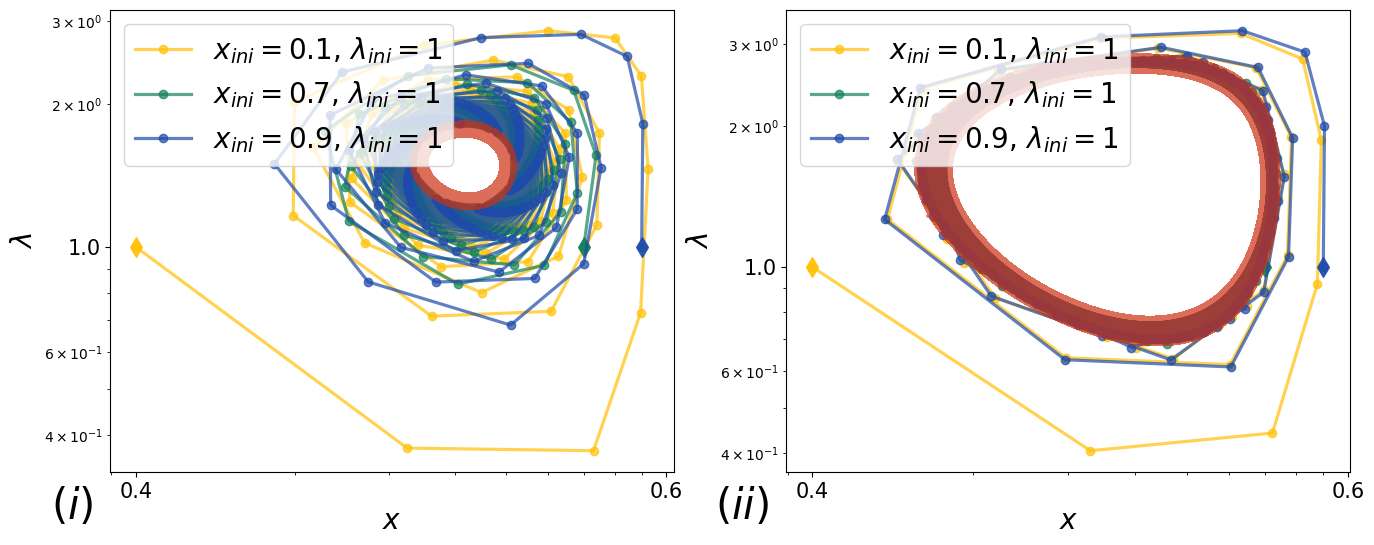

In [3]:
## 2 species ##

Klist, d = [29, 32], 10
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))


for j, ax in enumerate([ax1, ax2]):
    K = Klist[j]
    def lamnp1(lam, x):
        return (lam+K*(1.-np.exp(-lam*x)))/d

    def xp1(lam, x):
        return (lam*x+K*np.exp(-lam)*(np.exp(lam*x)-1.))/(lam+K*(1.-np.exp(-lam*x)))

    x00, x01, x02, lam0, = 0.1, 0.7, 0.9, 1

    xlist0, xlist1, xlist2, lamlist0, lamlist1, lamlist2 = [x00], [x01], [x02], [lam0], [lam0], [lam0]
    for i in range(300):
        xlist0.append(xp1(lamlist0[-1], xlist0[-1]))
        lamlist0.append(lamnp1(lamlist0[-1], xlist0[-2]))
        xlist1.append(xp1(lamlist1[-1], xlist1[-1]))
        lamlist1.append(lamnp1(lamlist1[-1], xlist1[-2]))
        xlist2.append(xp1(lamlist2[-1], xlist2[-1]))
        lamlist2.append(lamnp1(lamlist2[-1], xlist2[-2]))

    ax.scatter(x00, lam0, marker='d', s=100, color = carr[0], alpha=0.9, zorder=2)
    ax.plot(xlist0, lamlist0, 'o-', lw=2.3, color = carr[0], alpha=0.7, label=r'$x_{ini}$'+r'$={}$'.format(x00) + r'$,\,\lambda_{ini}$'+r'$={}$'.format(lam0), zorder=0)
    ax.scatter(x01, lam0, marker='d', s=100, color = carr[8], alpha=0.9, zorder=1)
    ax.plot(xlist1, lamlist1, 'o-', lw=2.3, color = carr[8], alpha=0.7, label=r'$x_{ini}$'+r'$={}$'.format(x01) + r'$,\,\lambda_{ini}$'+r'$={}$'.format(lam0), zorder=1)
    ax.scatter(x02, lam0, marker='d', s=100, color = carr[10], alpha=0.9, zorder=0)
    ax.plot(xlist2, lamlist2, 'o-', lw=2.3, color = carr[10], alpha=0.7, label=r'$x_{ini}$'+r'$={}$'.format(x02) + r'$,\,\lambda_{ini}$'+r'$={}$'.format(lam0), zorder=2)
    ax.set_xlabel(r'$x$', fontsize=20)
    ax.set_ylabel(r'$\lambda$', fontsize=20)
    #ax.set_xlim(0. , 1.)
    #ax.set_ylim(0. , 4)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(fontsize=20, loc='upper left')
    ax.text(-0.03, -0.03, r'$(i)$' if j==0 else r'$(ii)$', transform=ax.transAxes, fontsize=30, fontweight='bold', va='top', ha='right')
    ax.set_xticklabels([0., 0.2, 0.4, 0.6, 0.8, 1.], fontsize=15)
    ax.set_yticklabels([0., 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 4.], fontsize=15)

    x0p, l0p = (d-1)/K+1E-2, np.log(K/(d-1))+1E-2
    xlistp, lam0p = [x0p], [l0p]
    for i in range(int(1E5)):
        xlistp.append(xp1(lam0p[-1], xlistp[-1]))
        lam0p.append(lamnp1(lam0p[-1], xlistp[-2]))

    ax.plot(xlistp[2500:], lam0p[2500:], '-', lw=10, alpha=0.7, zorder=5, color = carr[3])


27.18281828459045
EigResult(eigenvalues=array([-0.45+0.87904378j, -0.45-0.87904378j]), eigenvectors=array([[ 0.949861  +0.j        ,  0.949861  -0.j        ],
       [-0.14247915+0.27832314j, -0.14247915-0.27832314j]]))


(0.0, 2.0)

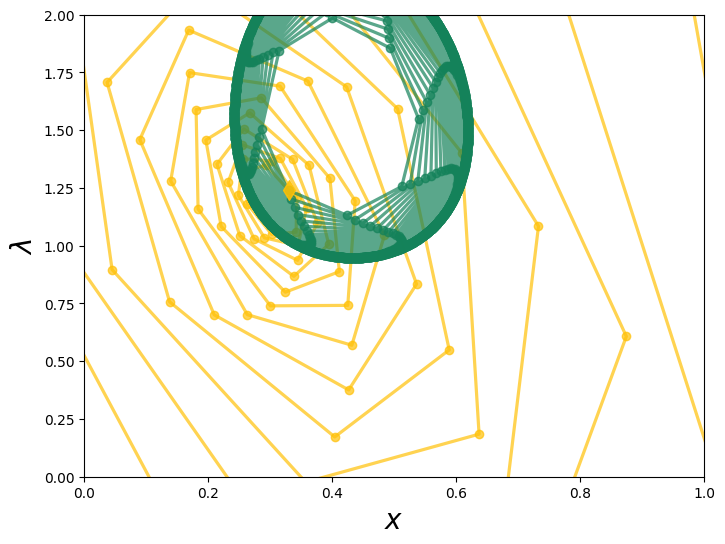

In [4]:
K, d = 30., 10 #11.5562287502, 10 #27.3396, 10
print(d*np.e)

def mup1(eps, mu):
    return mu+K*eps/d

def epsp1(eps, mu):
    return eps-((np.log(K/(d-1))*(d-1)**2/(d*K))*mu + (d-1)/d * eps)

def lamnp1(lam, x):
    return (lam+K*(1.-np.exp(-lam*x)))/d

def xp1(lam, x):
    return (lam*x+K*np.exp(-lam)*(np.exp(lam*x)-1.))/(lam+K*(1.-np.exp(-lam*x)))

eig = np.linalg.eig(np.array([[0,K/d],[-((np.log(K/(d-1))*(d-1)**2/(d*K))), 1/d-1]]))
print(eig)

eps0, mu0 = 3E-2, 3E-2
xini, lamini = (d-1)/K, np.log(K/(d-1))
x0, lam0 = ((d-1)/K) + eps0, np.log(K/(d-1))*(1+mu0)
xlist0pert, lamlist0pert, = [x0], [lam0]
xlist0, lamlist0 = [x0], [lam0]

for i in range(int(3E3)):
    xlist0pert.append(xini + epsp1(xlist0pert[-1]-xini, lamlist0pert[-1]/lamini - 1))
    lamlist0pert.append(lamini*(1. + mup1(xlist0pert[-2]-xini, lamlist0pert[-1]/lamini - 1)) )
    xlist0.append(xp1(lamlist0[-1], xlist0[-1]))
    lamlist0.append(lamnp1(lamlist0[-1], xlist0[-2]))

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(x0, lam0, marker='d', s=100, color = carr[0], alpha=0.9, zorder=2)
ax.plot(xlist0pert, lamlist0pert, 'o-', lw=2.3, color = carr[0], alpha=0.7, label=r'$x_{ini}$'+r'$={}$'.format(x0) + r'$,\,\lambda={}$'.format(lam0), zorder=0)
ax.plot(xlist0, lamlist0, 'o-', lw=2.3, color = carr[8], alpha=0.7, label=r'$x_{ini}$'+r'$={}$'.format(x0) + r'$,\,\lambda={}$'.format(lam0), zorder=1)
ax.set_xlabel(r'$x$', fontsize=20)
ax.set_ylabel(r'$\lambda$', fontsize=20)
ax.set_xlim(0. , 1.)
ax.set_ylim(0. , 2.)
#ax.legend(fontsize=20)


/tmp/ipykernel_7593/2320996191.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0., 0.2, 0.4, 0.6, 0.8, 1.], fontsize=15)
/tmp/ipykernel_7593/2320996191.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([0., 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 4.], fontsize=15)
/tmp/ipykernel_7593/2320996191.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0., 0.2, 0.4, 0.6, 0.8, 1.], fontsize=15)
/tmp/ipykernel_7593/2320996191.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([0., 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 4.], fontsize=15)


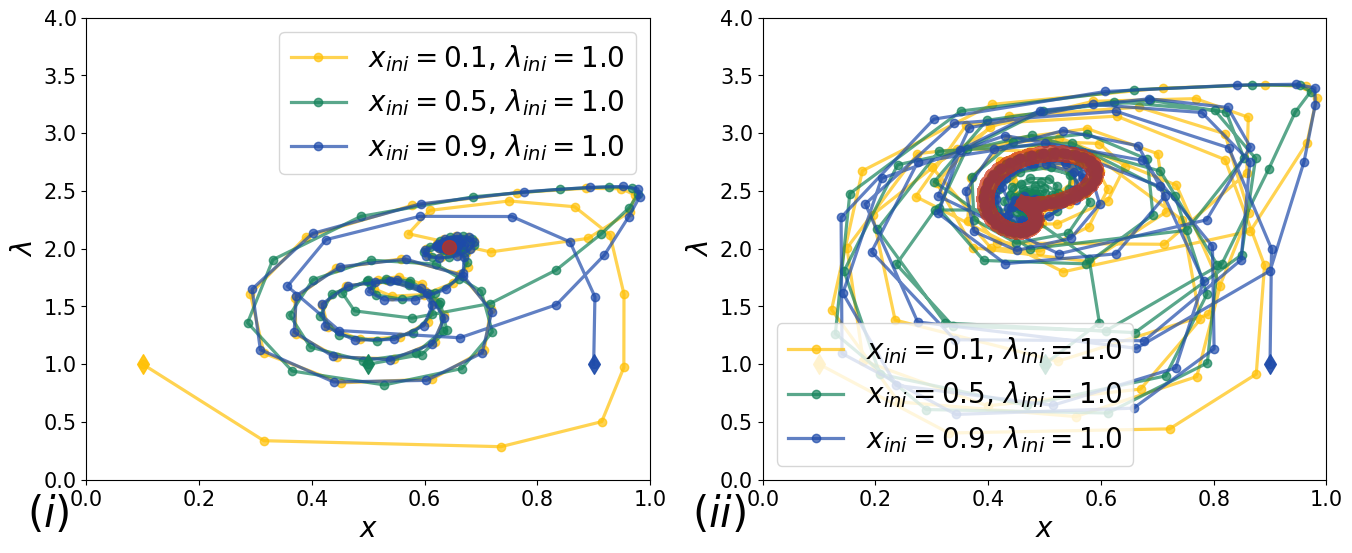

In [5]:
## Four species ##

Klist, d = [25, 32], 10
repet = int(3.E2)
cells = 5.E4
r=1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

for j, ax in enumerate([ax1, ax2]):
    K = Klist[j]

    alpha = np.array([[5.E-1,0.],[0.,2.E0]])
    gamma = np.array([[7.E0,0.],[0.,2.E1]])
    mu = np.array([1.E-2,0.])
    nu = np.array([1.E-2,1.E-2])

    T=1.E0*K/(alpha[0][0]*(K+1))

    x00, x01, x02, lam0, = 0.1, 0.5, 0.9, 1.

    xlist0, xlist1, xlist2, lamlist0, lamlist1, lamlist2 = [x00], [x01], [x02], [lam0], [lam0], [lam0]

    compart_dyn_theo_deter = theory_compart(T, K, d, x00, 0., 1-x00, 1., repet, alpha, gamma, mu, nu, ratiolen = r)
    hist_evol_theo, hist_evol_theo_numb, lamlist0 = compart_dyn_theo_deter.evol(lambdaarr=True)
    hist_evol_theo = np.array(hist_evol_theo)
    xlist0 = hist_evol_theo[:-1,0,0] + hist_evol_theo[:-1,0,1]

    compart_dyn_theo_deter = theory_compart(T, K, d, x01, 0., 1-x01, 1., repet, alpha, gamma, mu, nu, ratiolen = r)
    hist_evol_theo, hist_evol_theo_numb, lamlist1 = compart_dyn_theo_deter.evol(lambdaarr=True)
    hist_evol_theo = np.array(hist_evol_theo)
    xlist1 = hist_evol_theo[:-1,0,0] + hist_evol_theo[:-1,0,1]

    compart_dyn_theo_deter = theory_compart(T, K, d, x02, 0., 1-x02, 1., repet, alpha, gamma, mu, nu, ratiolen = r)
    hist_evol_theo, hist_evol_theo_numb, lamlist2 = compart_dyn_theo_deter.evol(lambdaarr=True)
    hist_evol_theo = np.array(hist_evol_theo)
    xlist2 = hist_evol_theo[:-1,0,0] + hist_evol_theo[:-1,0,1]

    ax.scatter(x00, lam0, marker='d', s=100, color = carr[0], alpha=0.9, zorder=2)
    ax.plot([x00]+list(xlist0[1:]), [lam0]+list(lamlist0[:-1]), 'o-', lw=2.3, color = carr[0], alpha=0.7, label=r'$x_{ini}$'+r'$={}$'.format(x00) + r'$,\,\lambda_{ini}$'+r'$={}$'.format(lam0), zorder=0)
    ax.scatter(x01, lam0, marker='d', s=100, color = carr[8], alpha=0.9, zorder=3)
    ax.plot([x01]+list(xlist1[1:]), [lam0]+list(lamlist1[:-1]), 'o-', lw=2.3, color = carr[8], alpha=0.7, label=r'$x_{ini}$'+r'$={}$'.format(x01) + r'$,\,\lambda_{ini}$'+r'$={}$'.format(lam0), zorder=1)
    ax.scatter(x02, lam0, marker='d', s=100, color = carr[10], alpha=0.9, zorder=0)
    ax.plot([x02]+list(xlist2[1:]), [lam0]+list(lamlist2[:-1]), 'o-', lw=2.3, color = carr[10], alpha=0.7, label=r'$x_{ini}$'+r'$={}$'.format(x02) + r'$,\,\lambda_{ini}$'+r'$={}$'.format(lam0), zorder=2)
    ax.set_xlabel(r'$x$', fontsize=20)
    ax.set_ylabel(r'$\lambda$', fontsize=20) 
    ax.set_xlim(0. , 1.)
    ax.set_ylim(0. , 4)
    #ax.set_xscale('log')
    #ax.set_yscale('log')
    ax.set_xticklabels([0., 0.2, 0.4, 0.6, 0.8, 1.], fontsize=15)
    ax.set_yticklabels([0., 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 4.], fontsize=15)
    ax.legend(fontsize=20, loc='best')

    compart_dyn_theo_deter = theory_compart(T, K, d, x00, 0., 1-x00, 1., int(5E4), alpha, gamma, mu, nu, ratiolen = r)
    hist_evol_theo, hist_evol_theo_numb, lamlist3 = compart_dyn_theo_deter.evol(lambdaarr=True)
    hist_evol_theo = np.array(hist_evol_theo)
    xlist3 = hist_evol_theo[:-1,0,0] + hist_evol_theo[:-1,0,1]
    if j==1:
        ax.plot(xlist3[int(4.95E4+1):], lamlist3[int(4.95E4):-1], '-', lw=10., alpha=0.7, zorder=5, color = carr[3])
    else:
        ax.scatter(xlist3[-1], lamlist3[-2], marker='o', s=100., alpha=0.7, zorder=5, color = carr[3])
    ax.text(-0.03, -0.03, r'$(i)$' if j==0 else r'$(ii)$', transform=ax.transAxes, fontsize=30, fontweight='bold', va='top', ha='right')

fig.savefig(cd + '/results/fig_oscillations_4sp.pdf', dpi=100)